## **TMDB Movie Data Analysis using Pandas and APIs**


In [2]:
import sys
import pandas as pd
import numpy as np
from dotenv import load_dotenv
import matplotlib.pyplot as plt
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent 
sys.path.insert(0, str(PROJECT_ROOT))
from src.kpis.metrics import add_kpi_columns


### **Data Visualization**
Visually comparing some metrices for clear and better understanding of different movie performance.

Let us start by loading our cleaned and transformed movies dataset:


In [3]:
SILVER = Path("../data/silver/tmdb_movies_silver.parquet")
GOLD_DIR = Path("../data/gold")

df = pd.read_parquet(SILVER)

top_revenue = pd.read_csv(GOLD_DIR / "top_revenue.csv")
top_profit  = pd.read_csv(GOLD_DIR / "top_profit.csv")
fr_vs_std   = pd.read_csv(GOLD_DIR / "franchise_vs_standalone.csv")

df.head()

,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,vote_average,popularity,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size
0,109445,Frozen,Who will save the day? The ice guy? The nice g...,2013-11-20,Animation|Family|Adventure|Fantasy,Frozen Collection,en,150.0,1274.219009,Walt Disney Animation Studios,...,7.200,16.3137,102,Young princess Anna of Arendelle dreams about ...,English,/kgwjIb2JDHRhNk13lmSxiClFjVk.jpg,Idina Menzel|Kristen Bell|Jonathan Groff|Josh ...,60,Chris Buck,285
1,12445,Harry Potter and the Deathly Hallows: Part 2,It all ends.,2011-07-12,Adventure|Fantasy,Harry Potter Collection,en,125.0,1341.511219,Warner Bros. Pictures|Heyday Films,...,8.100,15.9078,130,"Harry, Ron and Hermione continue their quest t...",English,/c54HpQmuwXjHq2C9wmoACjxoom3.jpg,Daniel Radcliffe|Emma Watson|Rupert Grint|Ralp...,105,David Yates,160
2,135397,Jurassic World,The park is open.,2015-06-06,Action|Adventure|Science Fiction|Thriller,Jurassic Park Collection,en,150.0,1671.537444,Amblin Entertainment|Universal Pictures|Legend...,...,6.698,11.0871,124,Twenty-two years after the events of Jurassic ...,English,/rhr4y79GpxQF9IsfJItRXVaoGs4.jpg,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,53,Colin Trevorrow,428
3,140607,Star Wars: The Force Awakens,Every generation has a story.,2015-12-15,Adventure|Action|Science Fiction,Star Wars Collection,en,245.0,2068.223624,Lucasfilm Ltd.|Bad Robot,...,7.200,11.2760,136,Thirty years after defeating the Galactic Empi...,English,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,183,J.J. Abrams,265
4,168259,Furious 7,Vengeance hits home.,2015-04-01,Action|Crime|Thriller,The Fast and the Furious Collection,en,190.0,1515.400000,Original Film|One Race|Universal Pictures,...,7.219,9.0259,139,Deckard Shaw seeks revenge against Dominic Tor...,Arabic|English|Spanish|Thai,/ktofZ9Htrjiy0P6LEowsDaxd3Ri.jpg,Vin Diesel|Paul Walker|Dwayne Johnson|Michelle...,49,James Wan,228


Now let us first add the kpi columns to support visualizations later

In [4]:
df = add_kpi_columns(df)

2026-02-24 16:03:44 | INFO | tmdb_pipeline | add_kpi_columns: adding profit_musd and roi



#### **Revenue Vs budget**

We want to know how the revenue generated from each movie compares to its budget. We will use a reference line of the budget in our data multiplied by 5.


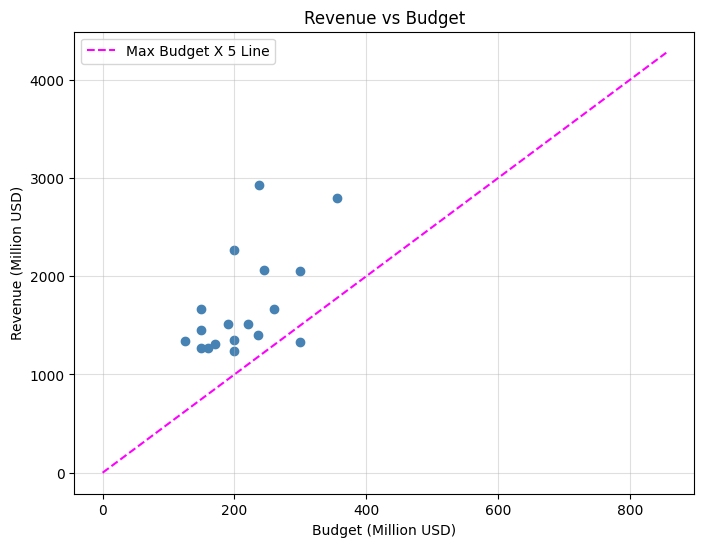

In [5]:
plot_df = df.copy()
plot_df = plot_df.dropna(subset=["budget_musd", "revenue_musd"])
plot_df = plot_df[(plot_df["budget_musd"] > 0) & (plot_df["revenue_musd"] > 0)]
plt.figure(figsize=(8,6))

plt.scatter(plot_df["budget_musd"], plot_df["revenue_musd"], c="steelblue")

# Reference line
max_budget = plot_df["budget_musd"].max()
roi_x = range(0, int(max_budget)+500)
roi_y = [x * 5 for x in roi_x]
plt.plot(roi_x, roi_y, "--", color="magenta", label="Max Budget X 5 Line")

plt.xlabel("Budget (Million USD)")
plt.ylabel("Revenue (Million USD)")
plt.title("Revenue vs Budget")
plt.legend()
plt.grid(alpha=0.4)
plt.show()


In [6]:
under_5x = plot_df[plot_df["revenue_musd"] < 5 * plot_df["budget_musd"]]

under_5x[["title", "budget_musd", "revenue_musd", "profit_musd", "roi"]]

,title,budget_musd,revenue_musd,profit_musd,roi
5,Star Wars: The Last Jedi,300.0,1332.69883,1032.69883,4.442329


Movies above the red line achieved exceptionally high ROI. Most titles fall on a positive trend. This means that movies with higher budgets generally earn more revenue, but only a few come close to achieving very high returns relative to what they cost. This shows that while larger productions tend to make more money overall, they are not always the most financially efficient.

There was only one movie (**Star Wars: The Last Jedi**) whose revenue failed to exceed 5 times its budget and it is among the ones with the highest budgets in our data.

#### **ROI Distribution by Genre**

Now for the genre analysis. Let us lookat the mean Return on Ivestment by genre.

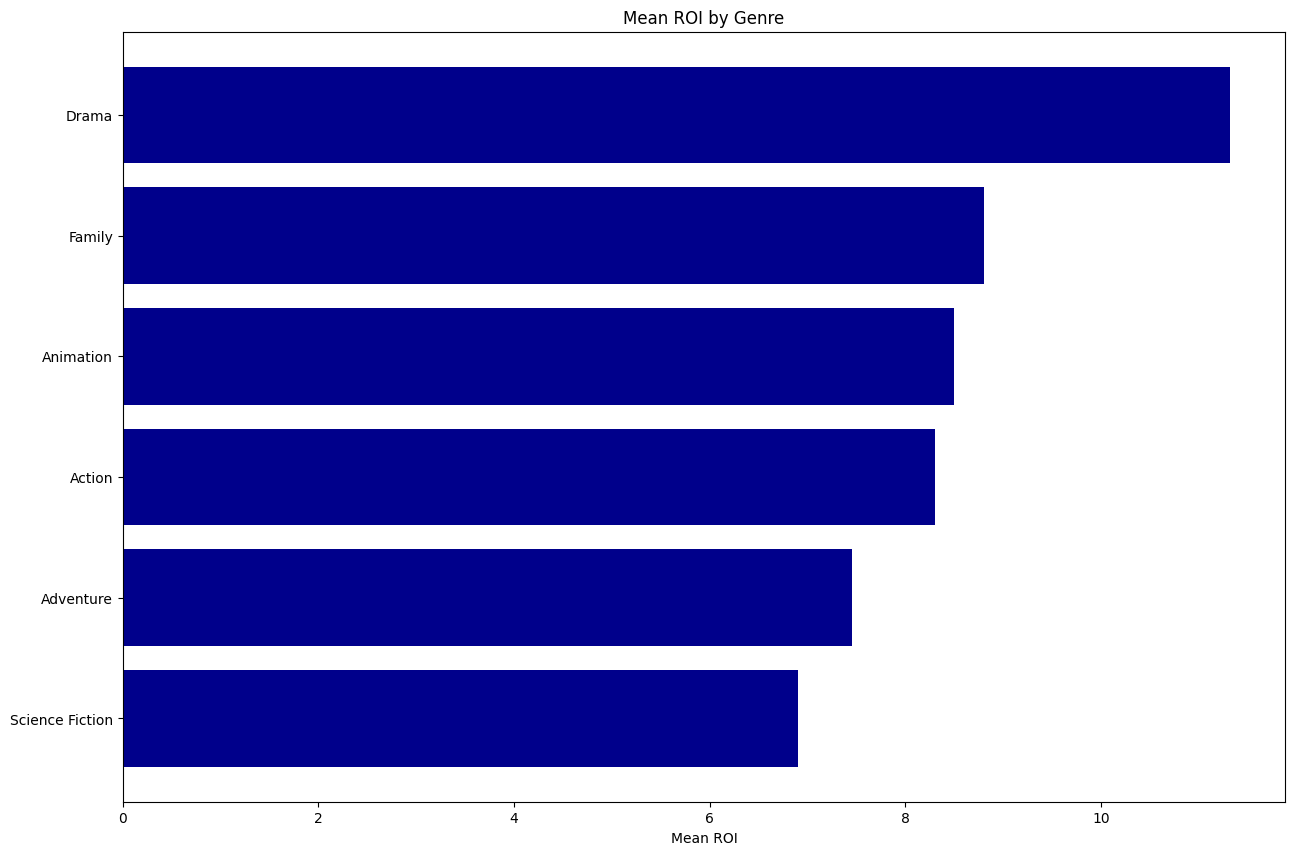

In [7]:
# compute mean ROI per primary genre
roi_mean = (
    plot_df.dropna(subset=["roi"])
            .assign(primary_genre=lambda df: df["genres"].str.split("|").str[0])
            .groupby("primary_genre")["roi"]
            .mean()
            .sort_values()
)

plt.figure(figsize=(15,10))
plt.barh(roi_mean.index, roi_mean.values, color="darkblue")
plt.xlabel("Mean ROI")
plt.title("Mean ROI by Genre")
plt.show()

Drama and Family movies tend to give the best return for the money spent, while genres like Animation and Action still perform well but with slightly lower efficiency. Adventure and Science Fiction show the smallest returns compared to their production costs. Overall, some of the less effects-heavy genres appear to stretch their budgets a bit further.

#### **Popularity vs. Rating**

One would want to check if the movies' rating really depends on their popularity. So that is what we are going to do now.

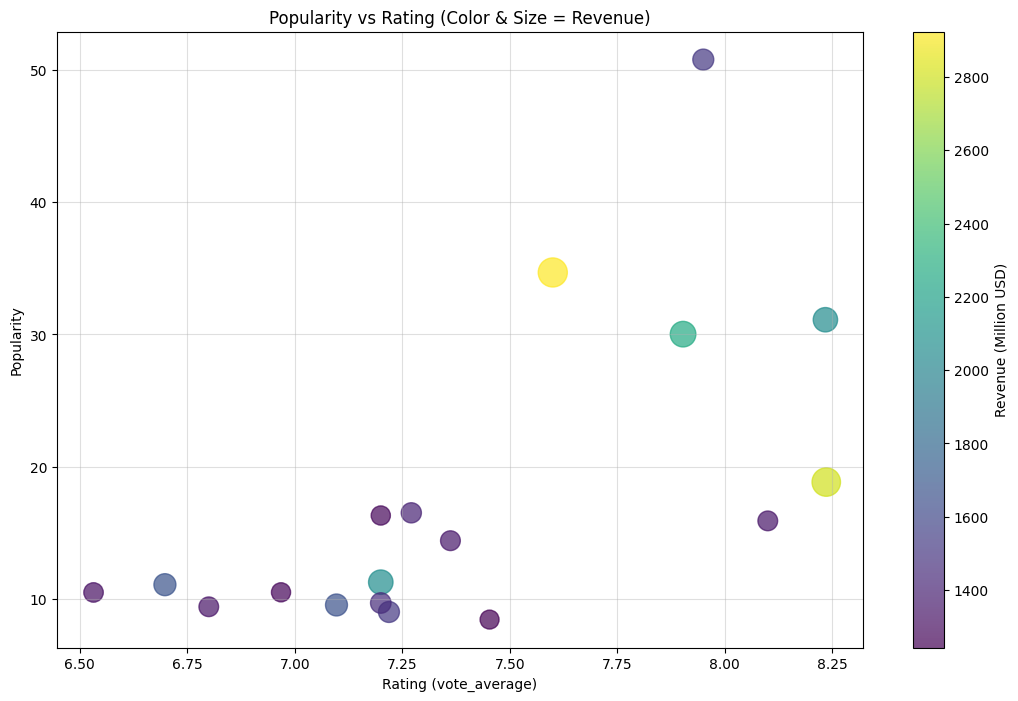

In [8]:
plt.figure(figsize=(13,8))

sizes = plot_df["revenue_musd"] * 0.15
colors = plot_df["revenue_musd"]    

scatter = plt.scatter(
    plot_df["vote_average"],
    plot_df["popularity"],
    s=sizes,
    c=colors,
    alpha=0.7,
    cmap="viridis"     
)

plt.xlabel("Rating (vote_average)")
plt.ylabel("Popularity")
plt.title("Popularity vs Rating (Color & Size = Revenue)")
plt.grid(alpha=0.4)

cbar = plt.colorbar(scatter)
cbar.set_label("Revenue (Million USD)")

plt.show()

Movies with higher ratings don’t always have the highest popularity, but the ones that are both well-rated and widely talked about stand out clearly. The larger bubbles show that the biggest earners tend to sit in this upper area, meaning revenue often follows a mix of strong audience interest withmost especially good ratings.

#### **Trends in Box Office Performance**

Does Revenue generated by a movie really depend on its release date? We are going to see the annual released movies trend of revenue generated.

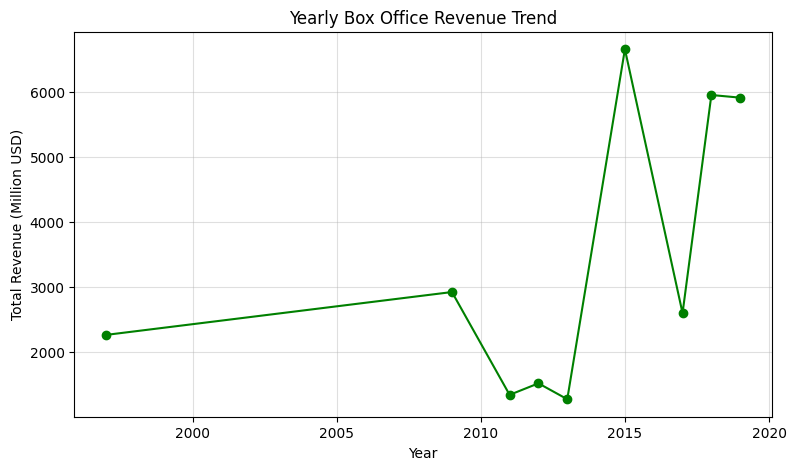

In [9]:
plot_df["release_date"] = pd.to_datetime(plot_df["release_date"], errors="coerce")

plot_df["year"] = plot_df["release_date"].dt.year

yearly = plot_df.groupby("year")["revenue_musd"].sum()

plt.figure(figsize=(9,5))
plt.plot(yearly.index, yearly.values, "-o", color="green")
plt.xlabel("Year")
plt.ylabel("Total Revenue (Million USD)")
plt.title("Yearly Box Office Revenue Trend")
plt.grid(alpha=0.4)
plt.show()


Total revenue changes a lot from year to year in this dataset. There’s a clear dip around 2010–2012, followed by a sharp jump in the mid-2010s when some very high-earning movies were released. The last few years stay relatively high, suggesting stronger titles in the later period of the dataset.

#### **Franchise vs. Standalone Success**

We saw earlier the comparison of movies that don't belong to any particular collection and those that do. The stand-alone movies performed relatively better. Let us visualize this for a more clear view and understanding.

<Figure size 700x600 with 0 Axes>

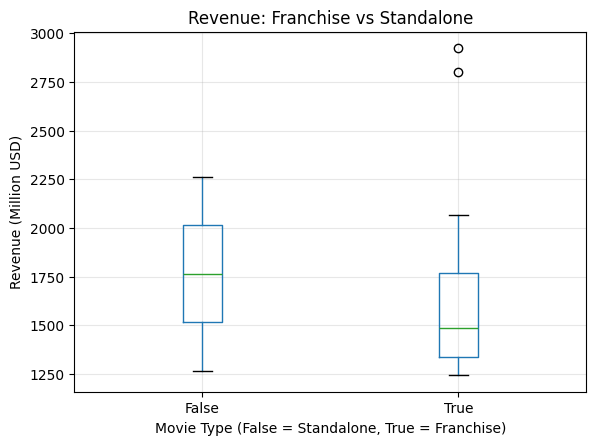

In [10]:
plot_df["is_franchise"] = plot_df["belongs_to_collection"].notna()
plt.figure(figsize=(7,6))
plot_df.boxplot(column="revenue_musd", by="is_franchise")
plt.title("Revenue: Franchise vs Standalone")
plt.suptitle("")
plt.xlabel("Movie Type (False = Standalone, True = Franchise)")
plt.ylabel("Revenue (Million USD)")
plt.grid(alpha=0.3)
plt.show()


Both standalone and franchise movies show a wide mix of revenues, but their typical values are fairly close. Standalone films sit a little higher in the middle range, while a few franchise titles rise far above the rest. This suggests that standalone typically does better, with franchises occasionally producing very big hits.

#### **Top Movies**

Let us also visualiza the most profitable movies for a clear comparison. This will give value to what we saw earlier. These are the top 10 movies:

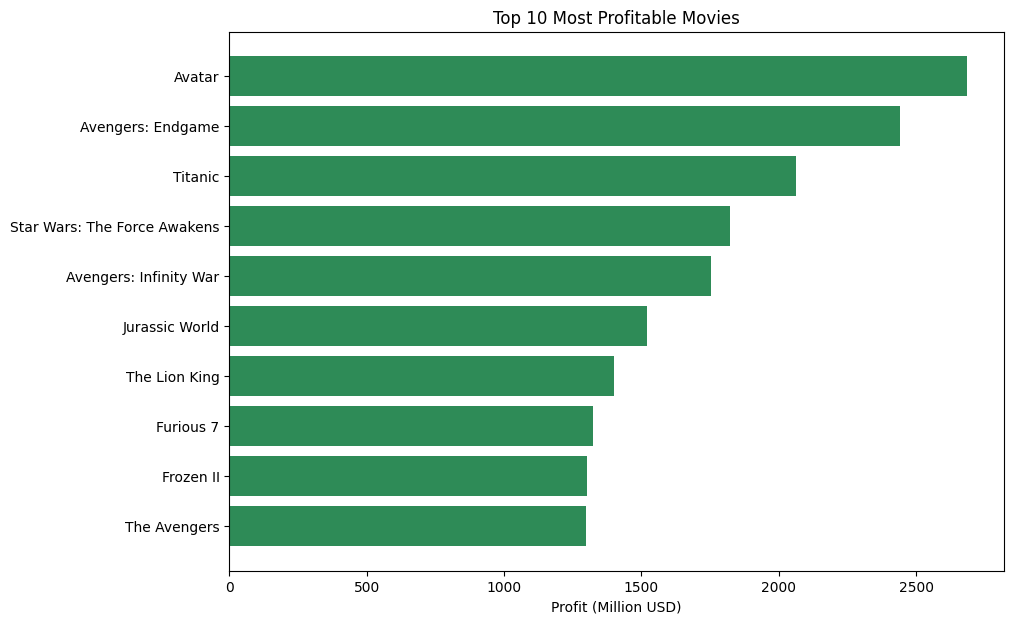

In [11]:
top_profit = plot_df.sort_values("profit_musd", ascending=False).head(10)

plt.figure(figsize=(10,7))
plt.barh(top_profit["title"], top_profit["profit_musd"], color="seagreen")
plt.xlabel("Profit (Million USD)")
plt.title("Top 10 Most Profitable Movies")
plt.gca().invert_yaxis()
plt.show()

Like we saw earlier, Avatar is the first. It is followed somewhat closely by Avengers: Endgame.

#### **Top Directors**
Now for the directors. A top 10 directors visual to add to the aggregation table

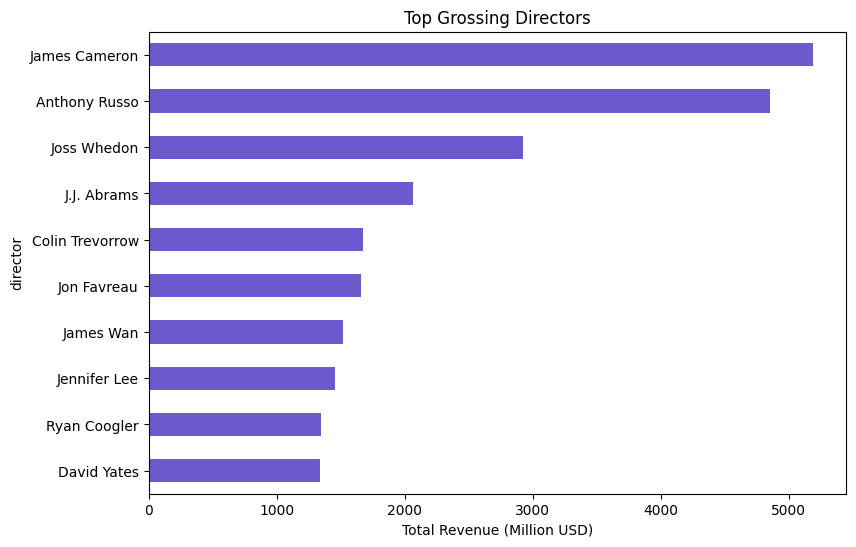

In [12]:
director_df = plot_df.groupby("director")["revenue_musd"].sum().sort_values(ascending=False)

plt.figure(figsize=(9,6))
director_df.head(10).plot(kind="barh", color="slateblue")
plt.xlabel("Total Revenue (Million USD)")
plt.title("Top Grossing Directors")
plt.gca().invert_yaxis()
plt.show()

This doesn't clearly capture the story we got from the table. We know that the first two Directors have 2 entries each in our data. This means that even though they have the most grossing revenue, it could be because we are adding up the revenue across thrir movies. So let us see the mean now.

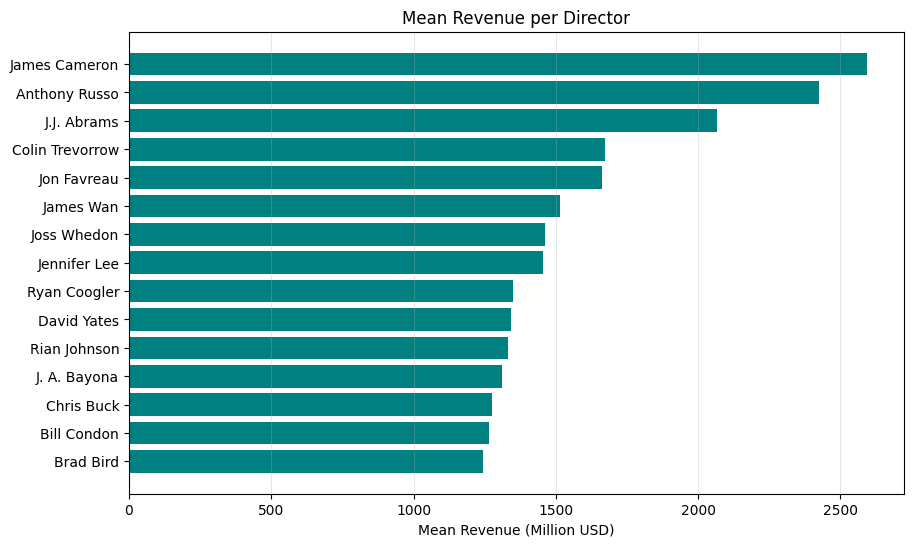

In [13]:
director_mean_rev = (
    plot_df
    .groupby("director")["revenue_musd"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,6))
bars = plt.barh(director_mean_rev.index, director_mean_rev.values, color="teal")
plt.xlabel("Mean Revenue (Million USD)")
plt.title("Mean Revenue per Director")
plt.grid(axis='x', alpha=0.3)

plt.show()

We see a slight shift now with J.J Abrams who came from the fifth to the third place as well as some others too. Joss Whedon moved back 4 places from the third to the seventh. But overall, the first two directors keep there places.